In [1]:
# Langchain import
from langchain.prompts import PromptTemplate, ChatPromptTemplate
from langchain_ollama import ChatOllama
from langchain_chroma import Chroma
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_core.documents import Document
from langgraph.graph import START, StateGraph

# Common import
from typing import List, TypedDict

# System import
import sys
sys.path.insert(0, "..")

# Local import
from utils.dto import QueryQuestion
from components.query_translation import query_translation
from components.query_analysis import query_analysis

In [2]:
# Enviroment import 
from dotenv import load_dotenv
import os
load_dotenv(dotenv_path=".env")
# Load environment variables
LANGSMITH_TRACING = os.getenv("LANGSMITH_TRACING")
LANGSMITH_ENDPOINT = os.getenv("LANGSMITH_ENDPOINT")
LANGSMITH_API_KEY = os.getenv("LANGSMITH_API_KEY")
LANGSMITH_PROJECT = os.getenv("LANGSMITH_PROJECT")

In [3]:
# Ollama model initialization
local_model = "llama3"
llm = ChatOllama(model=local_model, base_url="http://ollama:11434")
print(f"LLM model loaded: {llm.model}")

# Embedding model
model_name = "all-MiniLM-L6-v2"
# embedding_model = OllamaEmbeddings(model=model_name)
embedding_model = HuggingFaceEmbeddings(model_name=model_name)
print(f"Embedding model loaded: {embedding_model.model_name}")

# Vector store initialization
chunk_size = 3000
chunk_overlap = 300
persist_directory = f"../database/{model_name}/{chunk_size}_{chunk_overlap}"
vectordb_host = "vector-db"
vectordb_port = 8000
    
vector_store = Chroma(
    # persist_directory=persist_directory,
    host=vectordb_host,
    port=vectordb_port,
    collection_name="legislation",
    embedding_function=embedding_model,
)

LLM model loaded: llama3


/usr/local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Embedding model loaded: all-MiniLM-L6-v2


In [4]:
rag_template = """
Bạn là một luật sư giàu kinh nghiệm với vai trò tư vấn pháp lý cho khách hàng. Hãy trả lời câu hỏi của khách hàng bằng tiếng Việt CHỈ dựa trên các tài liệu đã cung cấp:
{context}
Câu hỏi: {question}
"""
prompt = ChatPromptTemplate.from_template(rag_template)

In [5]:
# Langgraph state definition
class State(TypedDict):
    raw_question: str
    query: str
    structured_query: str
    context: List[Document]
    answer: str

In [6]:
# Langgraph node definition
def translation(state: State):
    query = query_translation(state["raw_question"])
    return {"query": query}
    
def analysis(state: State):
    structured_query = query_analysis(state["query"])
    return {"structured_query": structured_query}
    
def retrieve(state: State):
    retrieved_docs = vector_store.similarity_search(state["structured_query"], k=5)
    return {"context": retrieved_docs}

def generate(state: State):
    docs_content = "\n\n".join(doc.page_content for doc in state["context"])
    messages = prompt.invoke({"question": state["structured_query"], "context": docs_content})
    response = llm.invoke(messages)
    return {"answer": response.content}

In [7]:
graph_builder = StateGraph(State).add_sequence([translation, analysis, retrieve, generate])
graph_builder.add_edge(START, "translation")
graph = graph_builder.compile()

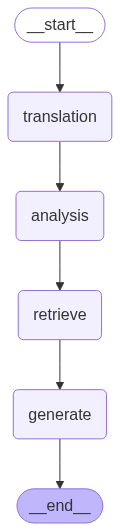

In [8]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [9]:
result = graph.invoke({"raw_question": "Các nguyên tắc cơ bản của hôn nhân và gia đình là gì?"})

print("Context:\n" + '\n'.join([f"{num + 1}/ {doc.page_content}" for num, doc in enumerate(result['context'])]))
print(f"\n\nAnswer: {result['answer']}")

Context:
1/ giá không thành thì Chấp hành viên quyết định giảm giá để tiếp tục bán đấu giá tài sản. 5. Mỗi lần giảm giá theo quy định tại các khoản 1, 3 và 4 Điều này không quá 10% giá khởi điểm của lần bán đấu giá liền kề trước đó.” 37. Sửa đổi, bổ sung các khoản 3, 4, 5 và 6 Điều 106 như sau:“3. Hồ sơ đăng ký chuyển quyền sở hữu, sử dụng gồm có: a) Văn bản đề nghị của cơ quan thi hành án dân sự; b) Bản sao bản án, quyết định; c) Quyết định thi hành án; d) Quyết định kê biên tài sản, nếu có; đ) Văn bản bán đấu giá thành hoặc quyết định giao tài sản, biên bản giao nhận tài sản để thi hành án; e) Giấy tờ khác có liên quan đến tài sản. 4. Trường hợp tài sản là quyền sử dụng đất, nhà ở và tài sản khác gắn liền với đất mà không có hoặc không thu hồi được Giấy chứng nhận quyền sử dụng đất, quyền sở hữu nhà ở và tài sản khác gắn liền với đất thì cơ quan có thẩm quyền có trách nhiệm cấp Giấy chứng nhận theo quy định của Chính phủ. 5. Đối với tài sản không thuộc trường hợp quy định tại khoản 4